# **Clustering de Pobreza Multidimensional en Colombia**

> Ana Sofía Salazar Álvarez, Johan Steven Avilan Peñaloza

---

# **Sección 1. Problema y datos**

---

## **1.1 ¿Qué queremos analizar y por qué?**

Cuando se habla de pobreza en Colombia, normalmente se resume la situación con una sola cifra: el porcentaje de hogares que se encuentran en condición de pobreza. Sin embargo, esa cifra no nos dice cómo son esos hogares ni cuáles son las dificultades específicas que enfrentan.

Esto nos lleva a plantear las siguientes preguntas:

> **¿Existen perfiles territoriales de pobreza multidimensional en Colombia?**
> **¿Qué combinaciones de privaciones caracterizan a cada tipo de hogar pobre?**

Para responder esta pregunta utilizaremos los datos a nivel de hogares del **Índice de Pobreza Multidimensional (IPM)**, incluidos en la **Encuesta Nacional de Calidad de Vida** del año 2025, una encuesta que busca capturar diferentes aspectos del bienestar de los hogares más allá del ingreso. El IPM está construido a partir de **15 indicadores de privación**, agrupados en cinco dimensiones principales:

* **Educación:** logro educativo, analfabetismo, inasistencia escolar y rezago escolar.
* **Salud:** acceso a servicios de salud, aseguramiento, barreras de acceso y trabajo infantil.
* **Trabajo:** desempleo de larga duración y empleo informal.
* **Vivienda:** material de pisos, material de paredes y hacinamiento.
* **Servicios públicos:** acceso a acueducto y alcantarillado.

Cada hogar encuestado puede describirse mediante estas 15 variables, que indican si presenta o no cada una de las privaciones consideradas por el IPM.

Nuestro interés es analizar si, a partir de estas características, es posible identificar **grupos de hogares con patrones similares de privación**. Por ejemplo, algunos hogares podrían concentrar sus dificultades en aspectos relacionados con la vivienda y los servicios públicos, mientras que otros podrían presentar principalmente rezagos en educación o empleo.

Para explorar esta estructura utilizaremos técnicas de análisis multivariado y aprendizaje no supervisado:

* **ACP** para reducir la dimensionalidad de los datos y visualizar posibles patrones.
* **K-Means** y **clustering jerárquico** para identificar grupos de hogares con características similares.

De esta manera, buscaremos comprender un poco mejor la pobreza multidimensional en Colombia y describir los distintos perfiles que pueden existir detrás de una misma cifra.


## **1.2 Carga del entorno y dataset**
Antes de iniciar el análisis, se cargan las librerías necesarias para el procesamiento de datos, la visualización de resultados y la aplicación de las técnicas de reducción de dimensionalidad y agrupamiento que se utilizarán más adelante.

También, se importan los datos a nivel de hogares del IPM de la **Encuesta Nacional de Calidad de Vida** (ECV 2025) disponibles en el portal de microdatos del [DANE](https://microdatos.dane.gov.co/index.php/catalog/903/get-microdata). Este conjunto de datos contiene la información descrita en la sección anterior


In [ ]:
# Librerías
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
# Carga del dataset desde Github con Pandas
url = "https://raw.githubusercontent.com/JohanAv1018/Proyecto-Final---Diplomado/main/IPM2025.csv"
ipm = pd.read_csv(url)


## **1.3 Exploración y limpieza de variables**
Una vez cargada la información, se realiza una revisión inicial de la estructura de los datos con el fin de verificar que las variables hayan sido importadas correctamente e identificar posibles problemas de calidad, tales como valores faltantes o inconsistencias en los registros y poder realizar la limpieza de ser necesaria.


### **1.3.1 Nuevo dataset para análisis**

Vamos a crear un dataset nuevo a partir del ya existente, que contenga las variables del IPM, junto con las variables `DEPARTAMENTO`, `POBRE` e `IPM`, que son las variables que nos interesa usar para el análisis.

In [ ]:
variables_ipm = [
    'logro_educativo',
    'analfabetismo',
    'inasistencia_escolar',
    'rezago_escolar',
    'atencion_integral',
    'trabajo_infantil',
    'aseguramiento_salud',
    'barreras_acceso_salud',
    'desempleo_larga_duracion',
    'empleo_formal',
    'acueducto',
    'alcantarillado',
    'pisos',
    'paredes',
    'hacinamiento'
]

variables_contexto = [
    'IPM',
    'POBRE',
    'DEPARTAMENTO'
]

ipm_analisis = ipm[variables_ipm + variables_contexto].copy()

### **1.3.2 Dimensiones y primer vistazo**

In [ ]:
# Dimensiones del conjunto de datos
print("Dimensiones:", ipm.shape)

# Información general
ipm_analisis.info()

Dimensiones: (87060, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87060 entries, 0 to 87059
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   logro_educativo           87060 non-null  int64  
 1   analfabetismo             87060 non-null  int64  
 2   inasistencia_escolar      87060 non-null  int64  
 3   rezago_escolar            87060 non-null  int64  
 4   atencion_integral         87060 non-null  int64  
 5   trabajo_infantil          87060 non-null  int64  
 6   aseguramiento_salud       87060 non-null  int64  
 7   barreras_acceso_salud     87060 non-null  int64  
 8   desempleo_larga_duracion  87060 non-null  int64  
 9   empleo_formal             87060 non-null  int64  
 10  acueducto                 87060 non-null  int64  
 11  alcantarillado            87060 non-null  int64  
 12  pisos                     87060 non-null  int64  
 13  paredes                   87060 non-

### **1.3.3 Valores faltantes**

In [ ]:
# Valores faltantes
ipm_analisis.isna().sum().sort_values(ascending=False)

,0
logro_educativo,0
analfabetismo,0
inasistencia_escolar,0
rezago_escolar,0
atencion_integral,0
trabajo_infantil,0
aseguramiento_salud,0
barreras_acceso_salud,0
desempleo_larga_duracion,0
empleo_formal,0


Podemos observar que no se encuentran valores faltantes en ninguna de las variables que vamos a analizar.

### **1.3.4 Registros duplicados**

In [ ]:
# Registros duplicados con dataset base
duplicados = ipm.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


Al hacer la verificación de registros duplicados con el dataset original, vemos que no tenemos ninguno, pues ningún hogar es exactamente igual a otro.

Como no tenemos ni registros duplicados, ni valores faltantes, podemos comenzar a utilizar el dataset para el análisis planteado inicialmente.


---

# **Sección 2. Modelado y Análisis**

---


## **2.1 Análisis de Componentes Principales**

Dado que los hogares de la muestra se describen mediante **15 indicadores** de privación asociados al **Índice de Pobreza Multidimensional (IPM)**, vamos a realizar un **Análisis de Componentes Principales (ACP)** para reducir la dimensionalidad preservando la mayor cantidad de información posible.

El gráfico de varianza explicada nos permite determinar cuántas componentes retener: buscamos el punto donde la varianza acumulada alcanza un umbral razonable sin incluir componentes que aporten muy poco.

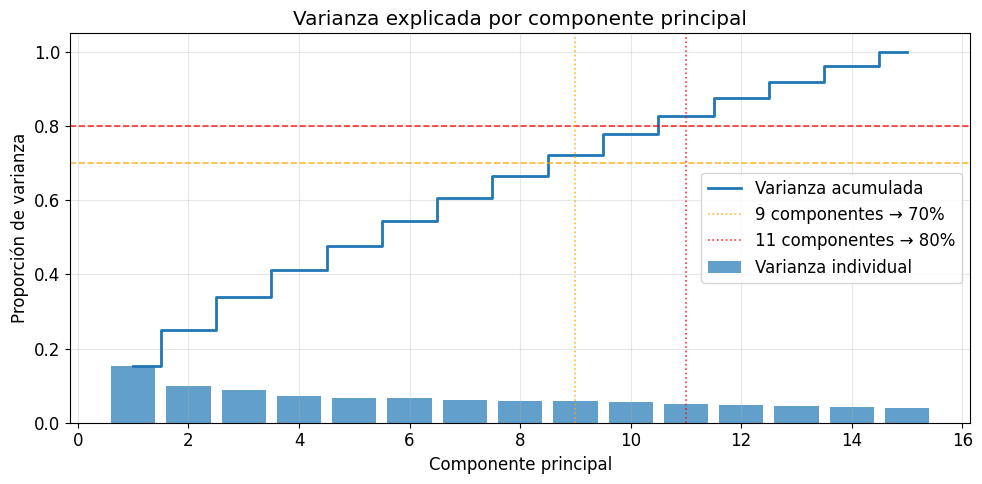

Componentes para explicar el 70% de la varianza: 9
Componentes para explicar el 80% de la varianza: 11


In [ ]:
# Variables para el PCA
X = ipm_analisis[variables_ipm]

# Estandarización de los indicadores
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Ajuste del PCA completo
pca = PCA()
pca.fit_transform(X_std)

# Varianza explicada
var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Número de componentes para umbrales de referencia
n_70 = np.argmax(var_cum >= 0.70) + 1
n_80 = np.argmax(var_cum >= 0.80) + 1

# Gráfico de varianza explicada
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(1, len(var_exp)+1), var_exp, alpha=0.7, label='Varianza individual')
ax.step(range(1, len(var_cum)+1), var_cum, where='mid', linewidth=2, label='Varianza acumulada')

ax.axhline(0.70, color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(0.80, color='red',    linestyle='--', linewidth=1.2, alpha=0.8)

ax.axvline(n_70, color='orange', linestyle=':', linewidth=1.2, alpha=0.8,
           label=f'{n_70} componentes → 70%')
ax.axvline(n_80, color='red',    linestyle=':', linewidth=1.2, alpha=0.8,
           label=f'{n_80} componentes → 80%')

ax.set_title("Varianza explicada por componente principal")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Componentes para explicar el 70% de la varianza: {n_70}")
print(f"Componentes para explicar el 80% de la varianza: {n_80}")

La varianza explicada se distribuye de forma gradual entre las componentes, lo cual es característico de variables binarias con correlaciones moderadas: no existe un "codo" pronunciado que indique un corte evidente.

Se identifican dos umbrales de referencia: **9 componentes** acumulan el 70% de la varianza y **11 componentes** el 80%. Vamos a guardar el análisis de componentes principales para ambos casos, con el fin de luego evaluar cual es el mejor con ayuda del número de clusters que se deseen identificar.

In [ ]:
# Se conservan ambas opciones para evaluación posterior
pca_9  = PCA(n_components=9).fit_transform(X_std)
pca_11 = PCA(n_components=11).fit_transform(X_std)

### **2.1.2 Visualización con t-SNE**

Con el espacio reducido por PCA es posible explorar visualmente si existen agrupaciones naturales en los datos. Sin embargo, dado que no es posible visualizar 9 u 11 dimensiones directamente, se aplica **t-SNE** para proyectar los hogares en dos dimensiones, coloreando cada punto según su valor del IPM.

Esto permite anticipar si los hogares con patrones similares de privación tienden a concentrarse en zonas diferenciadas del espacio, lo cual sería una señal favorable para el clustering que haremos más adelante.

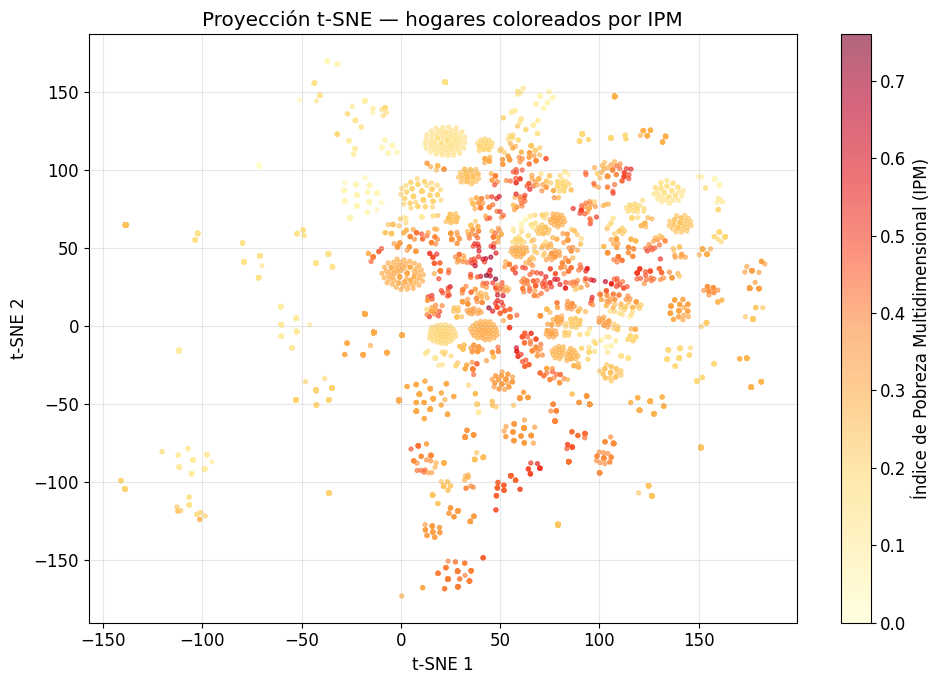

In [ ]:
# t-SNE sobre las 9 componentes (exploración inicial)
np.random.seed(42)
N_MUESTRA = 10_000
idx = np.random.choice(len(pca_9), size=min(N_MUESTRA, len(pca_9)), replace=False)

X_tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(pca_9[idx])

ipm_vals = ipm_analisis['IPM'].values[idx]

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=ipm_vals,
    cmap='YlOrRd',
    alpha=0.6,
    s=8
)

plt.colorbar(scatter, ax=ax, label='Índice de Pobreza Multidimensional (IPM)')
ax.set_title("Proyección t-SNE — hogares coloreados por IPM")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


La proyección no muestra grupos completamente separados, pero sí evidencia que los hogares no se distribuyen de manera uniforme. Se observa una concentración principal y varios grupos más dispersos, lo que sugiere la existencia de distintos **patrones de privación**.

Esta primera exploración respalda la idea de que los hogares pobres no son todos iguales y motiva la aplicación de técnicas de clustering para identificar perfiles con características similares.


## **2.2 Clustering**

Con el espacio reducido por PCA, se procede a identificar grupos de hogares con patrones similares de privación. Se implementan dos métodos de clustering: **K-Means** y **clustering jerárquico aglomerativo**. Antes de ajustar los modelos, es necesario determinar el número de clusters adecuado.

### **2.2.1 Selección del número de clusters (K)**

Vamos a evaluar dos criterios complementarios para valores de **K = 2 a 8**, y sobre **ambas configuraciones de PCA** (9 y 11 componentes), con el fin de decidir simultáneamente cuántos clusters retener y qué reducción dimensional usar:

- **Inercia (método del codo):** Para buscar el punto donde añadir un cluster adicional deja de reducir la inercia significativamente.

- **Coeficiente de Silhouette:** Mide qué tan bien separado está cada hogar de su propio cluster respecto a los demás. (Valores más cercanos a 1 indican clusters más definidos.)


── 9 componentes ──
  K=2 | Silhouette: 0.3540
  K=3 | Silhouette: 0.3301
  K=4 | Silhouette: 0.2942
  K=5 | Silhouette: 0.3036
  K=6 | Silhouette: 0.3324
  K=7 | Silhouette: 0.3197
  K=8 | Silhouette: 0.3932

── 11 componentes ──
  K=2 | Silhouette: 0.3354
  K=3 | Silhouette: 0.3452
  K=4 | Silhouette: 0.2373
  K=5 | Silhouette: 0.2796
  K=6 | Silhouette: 0.2965
  K=7 | Silhouette: 0.3241
  K=8 | Silhouette: 0.3232


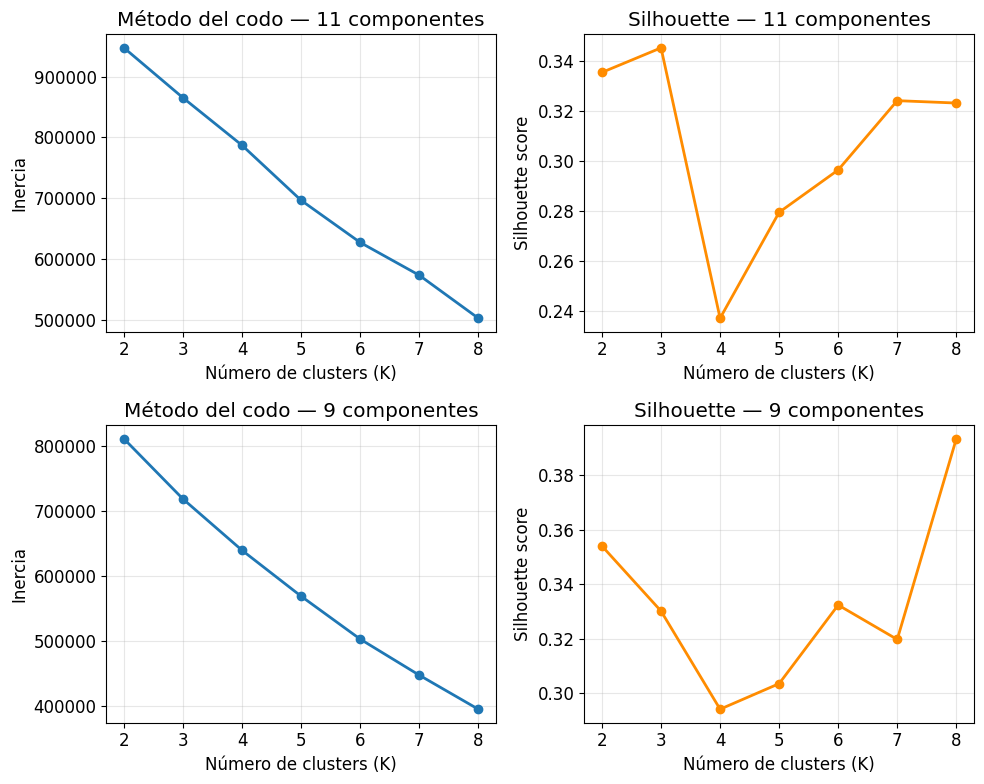

In [ ]:
ks = range(2, 9)
resultados = []

for nombre, X_red in [('9 componentes', pca_9), ('11 componentes', pca_11)]:
    inercias = []
    silhouettes = []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_red)
        inercias.append(km.inertia_)
        sil = silhouette_score(X_red, labels, sample_size=10_000, random_state=42)
        silhouettes.append(sil)
        resultados.append({'Componentes': nombre, 'K': k,
                           'Inercia': km.inertia_, 'Silhouette': sil})

    print(f"\n── {nombre} ──")
    for k, s in zip(ks, silhouettes):
        print(f"  K={k} | Silhouette: {s:.4f}")

# Visualización
df_res = pd.DataFrame(resultados)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, (nombre, grupo) in enumerate(df_res.groupby('Componentes')):

    # Codo
    axes[i, 0].plot(grupo['K'], grupo['Inercia'], marker='o', linewidth=2)
    axes[i, 0].set_title(f"Método del codo — {nombre}")
    axes[i, 0].set_xlabel("Número de clusters (K)")
    axes[i, 0].set_ylabel("Inercia")
    axes[i, 0].grid(alpha=0.3)

    # Silhouette
    axes[i, 1].plot(grupo['K'], grupo['Silhouette'],
                      marker='o', linewidth=2, color='darkorange')
    axes[i, 1].set_title(f"Silhouette — {nombre}")
    axes[i, 1].set_xlabel("Número de clusters (K)")
    axes[i, 1].set_ylabel("Silhouette score")
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **2.2.1.1 Selección final**

El método del codo no muestra un número óptimo de grupos de forma evidente. Por otro lado, aunque el coeficiente de Silhouette alcanza su valor más alto para **K = 8**, una solución con tantos grupos dificulta la interpretación de los resultados y la caracterización de los perfiles encontrados.

Teniendo en cuenta que el objetivo del estudio es identificar patrones generales de pobreza multidimensional, se opta por trabajar con **K = 3**, una partición más simple que permite describir y comparar los grupos de manera clara. El clustering se realizará sobre las **9 componentes principales**, seleccionadas previamente por resumir la mayor parte de la información contenida en los indicadores del IPM.


### **2.2.2 K-Means**

Con el número de clusters definido, vamos a ajustar el modelo **K-Means** sobre las 9 componentes del PCA.

In [ ]:
# Ajuste del modelo final
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km_final.fit_predict(pca_9)

# Distribución de hogares por cluster
cluster_counts = pd.Series(labels_km).value_counts().sort_index()
print("Hogares por cluster:")
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n:,} hogares ({n/len(labels_km)*100:.1f}%)")

Hogares por cluster:
  Cluster 0: 68,911 hogares (79.2%)
  Cluster 1: 2,899 hogares (3.3%)
  Cluster 2: 15,250 hogares (17.5%)


#### **2.2.2.1 Visualización de los clusters**

Una vez obtenidos los clusters, se visualizan sobre la proyección t-SNE y se analiza la incidencia de cada privación dentro de los grupos. Para ello, se utiliza un mapa de calor que permite comparar fácilmente los perfiles de pobreza identificados.

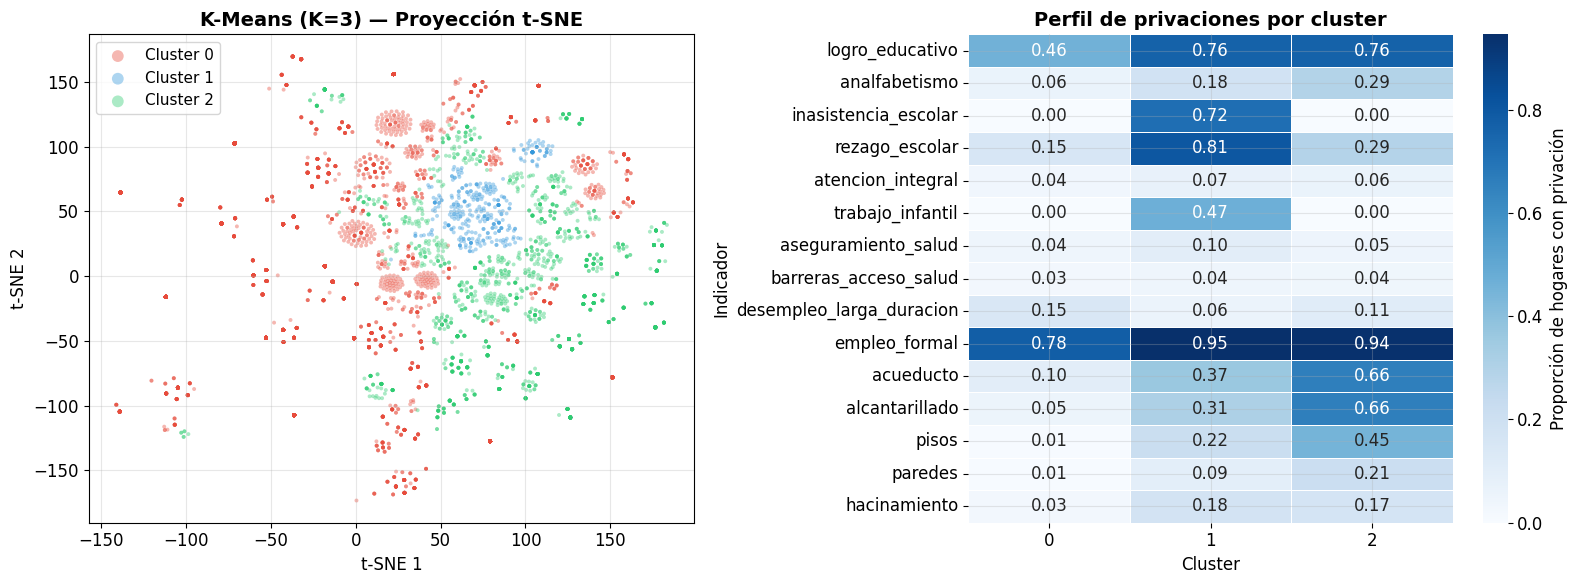

In [ ]:
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Clusters sobre t-SNE ---
labels_km_muestra = labels_km[idx]

for c in range(3):
    mask = labels_km_muestra == c
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=colors[c], label=f'Cluster {c}',
        alpha=0.4, s=8, edgecolors='none'
    )

axes[0].set_title('K-Means (K=3) — Proyección t-SNE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=3, fontsize=11)

# --- Perfil de privaciones por cluster ---
perfil = pd.DataFrame(X, columns=variables_ipm)
perfil['cluster'] = labels_km
medias = perfil.groupby('cluster')[variables_ipm].mean()

sns.heatmap(
    medias.T,
    ax=axes[1],
    cmap='Blues',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Proporción de hogares con privación'}
)

axes[1].set_title('Perfil de privaciones por cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Indicador')

plt.tight_layout()
plt.show()


#### **2.2.2.2 Perfiles de privaciones (Clustering por K-means)**

Los tres clusters muestran perfiles de pobreza bastante distintos entre sí.

- **Cluster 0:** Es el grupo con menor privación, el empleo informal es alto (0.78), pero en el resto de dimensiones los valores son bajos. Son hogares relativamente mejor posicionados dentro de la muestra.

- **Cluster 1:** Concentra las privaciones educativas más fuertes, tiene rezago escolar (0.81), inasistencia (0.72) y trabajo infantil (0.47) considerablemente altos. Son hogares donde los menores no están completando su trayectoria escolar, lo que tiene implicaciones que van más allá de la situación actual.

- **Cluster 2:** Se caracteriza por carencias en vivienda y servicios, sin acueducto ni alcantarillado (0.66 en ambos) y con materiales inadecuados en pisos (0.45). Un perfil más asociado a déficit de infraestructura que a otras dimensiones.

Finalmente, el **empleo informal** aparece como una **privación en todos los grupos**, con valores entre 0.78 y 0.95, lo que sugiere que no es un factor que diferencie los perfiles sino una condición típica en los hogares del IPM.

### **2.2.3 Clustering Jerárquico**

Usaremos clustering jerárquico para identificar cuántos grupos de hogares existen de forma natural. A diferencia de K-Means, este método nos genera un dendrograma que nos sugiere visualmente el número ideal de clusters sin tener que definirlo a ciegas.


#### **2.2.3.1 Dendograma**

Ya que el tamaño de dataset es grande, usaremos una muestra de 5.000 hogares para hacer el dendograma y para asignar los clusters al resto de hogares, se calculan los centroides de cada grupo en la muestra y se asigna cada hogar al centroide más cercano.

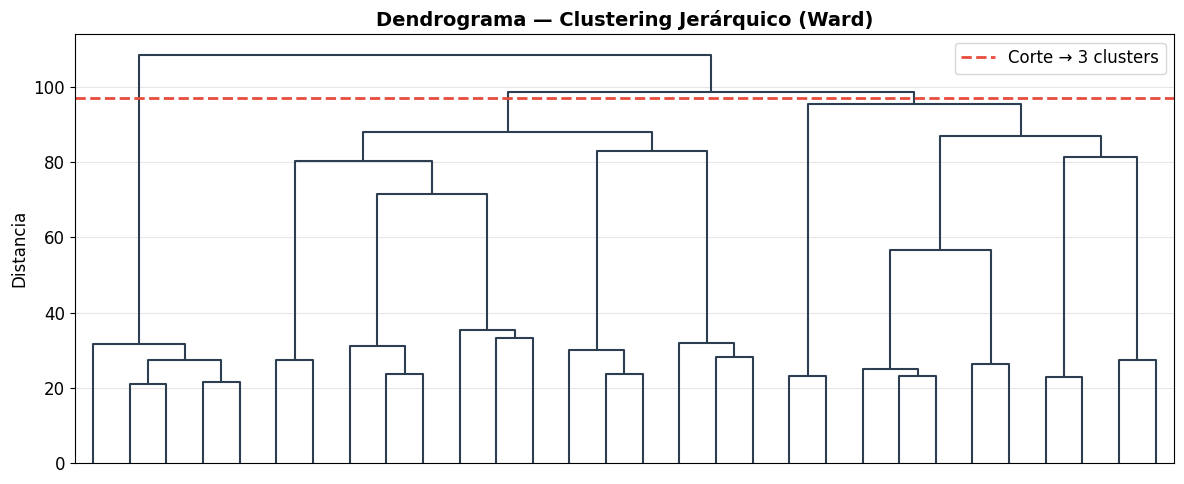

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Muestra para el dendrograma
np.random.seed(42)
idx_hier = np.random.choice(len(pca_9), size=5_000, replace=False)
X_hier = pca_9[idx_hier]

# Cálculo del linkage con método Ward
Z = linkage(X_hier, method='ward')

# Dendrograma
fig, ax = plt.subplots(figsize=(12, 5))

dendrogram(
    Z,
    ax=ax,
    no_labels=True,
    color_threshold=0,
    above_threshold_color='#2c3e50',
    truncate_mode='lastp',
    p=30
)

ax.set_title('Dendrograma — Clustering Jerárquico (Ward)', fontsize=14, fontweight='bold')
ax.set_ylabel('Distancia', fontsize=12)
ax.axhline(y=97, color='#e74c3c', linestyle='--', linewidth=2, label='Corte → 3 clusters')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

El dendrograma confirma la estructura planteada con K-Means, ya que un corte a la altura adecuada sugiere **3 grupos**, que es lo mismo que habíamos obtenido antes.
Con esto definido, se calculan los centroides de cada cluster y se asignan los 87,060 hogares por distancia a esos centroides

#### **2.2.3.2 Clustering jerarquico a la muestra**

In [ ]:
# Clustering jerárquico sobre la muestra
labels_hier_muestra = fcluster(Z, t=3, criterion='maxclust') - 1

# Centroides de cada cluster en la muestra
centroides_hc = np.array([
    X_hier[labels_hier_muestra == c].mean(axis=0)
    for c in range(3)
])

# Asignar cada hogar al centroide más cercano
from scipy.spatial.distance import cdist
distancias = cdist(pca_9, centroides_hc, metric='euclidean')
labels_hc = distancias.argmin(axis=1)

# Distribución
cluster_counts_hc = pd.Series(labels_hc).value_counts().sort_index()
print("Hogares por cluster:")
for c, n in cluster_counts_hc.items():
    print(f"  Cluster {c}: {n:,} hogares ({n/len(labels_hc)*100:.1f}%)")

Hogares por cluster:
  Cluster 0: 2,888 hogares (3.3%)
  Cluster 1: 68,705 hogares (78.9%)
  Cluster 2: 15,467 hogares (17.8%)


#### **2.2.3.3 Visualización de los clusters**

Al igual que con K-Means, vamos a analizar el perfil de privaciones de cada cluster para verificar si los grupos encontrados son consistentes entre ambos métodos.

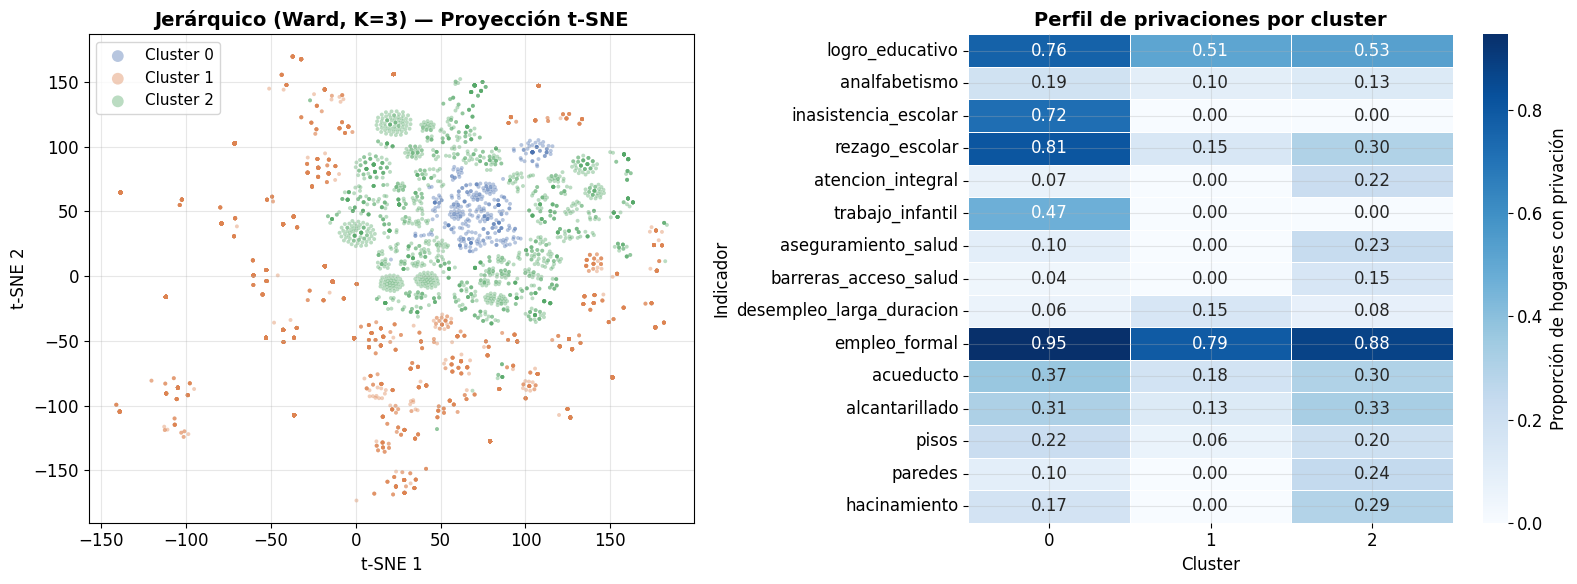

In [ ]:
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Clusters sobre t-SNE ---
labels_hc_muestra = labels_hc[idx]

for c in range(3):
    mask = labels_hc_muestra == c
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=colors[c], label=f'Cluster {c}',
        alpha=0.4, s=8, edgecolors='none'
    )

axes[0].set_title('Jerárquico (Ward, K=3) — Proyección t-SNE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=3, fontsize=11)

# --- Perfil de privaciones ---
perfil_hc = pd.DataFrame(X, columns=variables_ipm)
perfil_hc['cluster'] = labels_hc
medias_hc = perfil_hc.groupby('cluster')[variables_ipm].mean()

sns.heatmap(
    medias_hc.T,
    ax=axes[1],
    cmap='Blues',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Proporción de hogares con privación'}
)

axes[1].set_title('Perfil de privaciones por cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Indicador')

plt.tight_layout()
plt.show()

#### **2.2.3.4 Perfiles de privaciones (Clustering Jerárquico)**

Los perfiles del clustering jerárquico son similares a los perfiles de K-Means, aunque con algunas diferencias en la distribución de hogares entre clusters.

- **Cluster 0:** Agrupa los hogares con mayores privaciones educativas, aquí, la inasistencia escolar (0.72), rezago escolar (0.81) y trabajo infantil (0.47) son sus valores más altos.

- **Cluster 1:** Es el grupo con menor privación general, los valores son bajos en casi todas las dimensiones, con excepción del empleo informal (0.79). Son los hogares relativamente mejor posicionados de la muestra.

- **Cluster 2:** Presenta un perfil más disperso, hay privaciones moderadas en vivienda (paredes 0.24, hacinamiento 0.29), servicios públicos (acueducto 0.30, alcantarillado 0.33) y también en salud (aseguramiento 0.23, barreras de acceso 0.15).

El empleo informal sigue estando presenten en los tres grupos, confirmando lo observado con K-Means.

---

# **Sección 3. Interpretación**

---

Con los modelos ajustados, vamos a analizar los resultados obtenidos en la sección anterior, se incluyen los componentes principales, se comparan los dos métodos de clustering y se analiza si los perfiles encontrados tienen una dimensión territorial.

## **3.1 Interpretación del ACP**

Vamos a revisar las cargas de las primeras cuatro componentes para entender qué dimensiones de la pobreza está resumiendo cada una y qué variables tienen más peso en el espacio reducido.

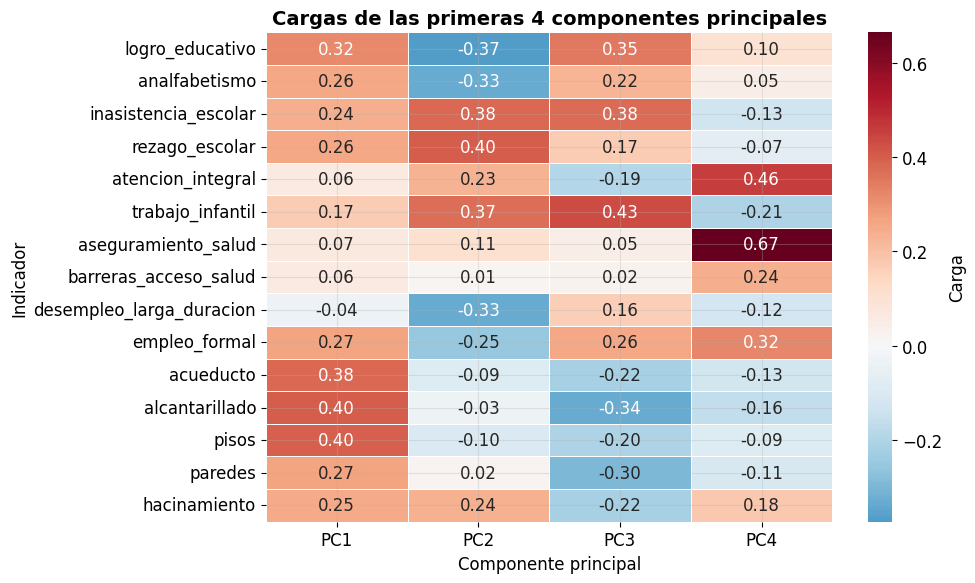

PC1: 15.2% de varianza explicada
PC2: 9.8% de varianza explicada
PC3: 8.9% de varianza explicada
PC4: 7.2% de varianza explicada


In [ ]:
# Cargas de las primeras 4 componentes
pca_interp = PCA(n_components=9)
pca_interp.fit(X_std)

loadings_df = pd.DataFrame(
    pca_interp.components_[:4].T,
    index=variables_ipm,
    columns=[f'PC{i+1}' for i in range(4)]
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    loadings_df,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Carga'}
)

ax.set_title('Cargas de las primeras 4 componentes principales', fontsize=14, fontweight='bold')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Indicador')

plt.tight_layout()
plt.show()

# Varianza explicada por componente
for i, v in enumerate(pca_interp.explained_variance_ratio_[:4]):
    print(f"PC{i+1}: {v*100:.1f}% de varianza explicada")

Las cuatro primeras componentes reflejan distintos tipos de privaciones presentes en los hogares.

La primera componente (PC1) está asociada principalmente con carencias en **servicios básicos** y **condiciones de la vivienda**, especialmente acueducto, alcantarillado y pisos. Por ello, puede interpretarse como una dimensión relacionada con la infraestructura del hogar.

La segunda componente (PC2) está más vinculada a aspectos **educativos** de los menores, como la inasistencia escolar, el rezago educativo y el trabajo infantil. Esta componente permite diferenciar hogares según sus condiciones educativas.

La tercera componente (PC3) combina variables **educativas** con algunas características de la **vivienda**, mostrando diferencias entre hogares que presentan problemas en educación y aquellos con mayores carencias habitacionales.

La cuarta componente (PC4) está relacionada principalmente con el acceso a **servicios de salud**, especialmente el aseguramiento y la atención integral.

En conjunto, estas componentes logran resumir las principales dimensiones de la pobreza multidimensional, facilitando la identificación de grupos de hogares con características similares.

## **3.2 Comparación entre métodos**

Antes de interpretar los perfiles, es importante verificar qué tan consistentes son las asignaciones entre **K-Means** y el clustering **jerárquico** y si ambos métodos agrupan los hogares de manera similar.

In [ ]:
# Tabla de contingencia entre ambos métodos
comparacion = pd.crosstab(
    labels_km,
    labels_hc,
    rownames=['K-Means'],
    colnames=['Jerárquico']
)

print("Tabla de contingencia (hogares):")
print(comparacion)
print()

# Porcentaje de acuerdo global
acuerdo = sum(comparacion.values.max(axis=1)) / len(labels_km)
print(f"Acuerdo global entre métodos: {acuerdo*100:.1f}%")

Tabla de contingencia (hogares):
Jerárquico     0      1     2
K-Means                      
0              0  60241  8670
1           2883      0    16
2              5   8464  6781

Acuerdo global entre métodos: 82.2%


Los resultados obtenidos con ambos métodos de agrupamiento son bastante similares. En total, el **82.2%** de los hogares fue clasificado en el **mismo grupo** por los dos algoritmos, lo que indica una **alta consistencia** entre las soluciones encontradas.

Los grupos **0** y **2** presentan la mayor **estabilidad**, mientras que el grupo **1** muestra algunas **diferencias entre métodos**. Esto es razonable porque se trata del cluster más pequeño, por lo que sus límites son menos claros que los de los demás grupos.

En general, la alta coincidencia observada sugiere que los perfiles identificados representan patrones reales presentes en los datos y no dependen únicamente del método de agrupamiento utilizado.

## **3.3 Perfiles de pobreza identificados**

Ambos métodos resultan en tres perfiles diferenciados. Para facilitar la comparación e interpretación, vamos a presentar un resumen de las características principales de cada grupo usando las asignaciones de K-Means como referencia.

In [ ]:
# Resumen estadístico de cada cluster
perfil_resumen = ipm_analisis.copy()
perfil_resumen['cluster'] = labels_km

resumen = perfil_resumen.groupby('cluster').agg(
    n_hogares=('IPM', 'count'),
    ipm_promedio=('IPM', 'mean'),
    pct_pobres=('POBRE', 'mean')
).reset_index()

resumen['pct_hogares'] = resumen['n_hogares'] / resumen['n_hogares'].sum() * 100

print("Resumen por cluster:")
print(resumen.to_string(index=False))

Resumen por cluster:
 cluster  n_hogares  ipm_promedio  pct_pobres  pct_hogares
       0      68911      0.168716    0.055405    79.153457
       1       2899      0.359245    0.604346     3.329887
       2      15250      0.322721    0.445377    17.516655


Los resultados muestran una distribución desigual de los hogares entre los tres grupos identificados.

El **Cluster 0** reúne cerca del **79%** de los hogares y presenta los niveles **más bajos de pobreza multidimensional**. Su IPM promedio es de 0.17 y solo el 5.5% de los hogares del grupo son considerados pobres, por lo que corresponde al perfil con mejores condiciones.

El **Cluster 1** es el grupo más pequeño, con apenas el **3.3%** de los hogares, pero también el **más vulnerable**. Presenta el IPM promedio más alto (0.36) y la mayor proporción de hogares pobres (60.4%), concentrando las situaciones de mayor privación.

Por su parte, el **Cluster 2** representa el **17.5%** de los hogares y ocupa una posición intermedia. Aunque registra **importantes carencias**, con un IPM promedio de 0.32 y una incidencia de pobreza del 44.5%, sus condiciones son menos críticas que las observadas en el Cluster 1.

## **3.4 Distribución territorial**

Para responder la pregunta sobre los **perfiles territoriales**, se analiza la distribución de cada cluster por departamento. Esto permite identificar si ciertos patrones de privación se concentran geográficamente.

In [ ]:
# Usamos geopandas (gpd) para crear la visualización.
base = "https://github.com/JohanAv1018/Proyecto-Final---Diplomado/raw/refs/heads/main/MGN2024_DPTO_POLITICO/"

archivos = [
    "MGN_ADM_DPTO_POLITICO.shp",
    "MGN_ADM_DPTO_POLITICO.shx",
    "MGN_ADM_DPTO_POLITICO.dbf",
    "MGN_ADM_DPTO_POLITICO.prj"
]

os.makedirs("shapefile", exist_ok=True)

for archivo in archivos:
    r = requests.get(base + archivo)
    with open(f"shapefile/{archivo}", 'wb') as f:
        f.write(r.content)

colombia = gpd.read_file("shapefile/MGN_ADM_DPTO_POLITICO.shp")
colombia['dpto_cnmbr'] = colombia['dpto_cnmbr'].str.encode('latin-1').str.decode('utf-8')

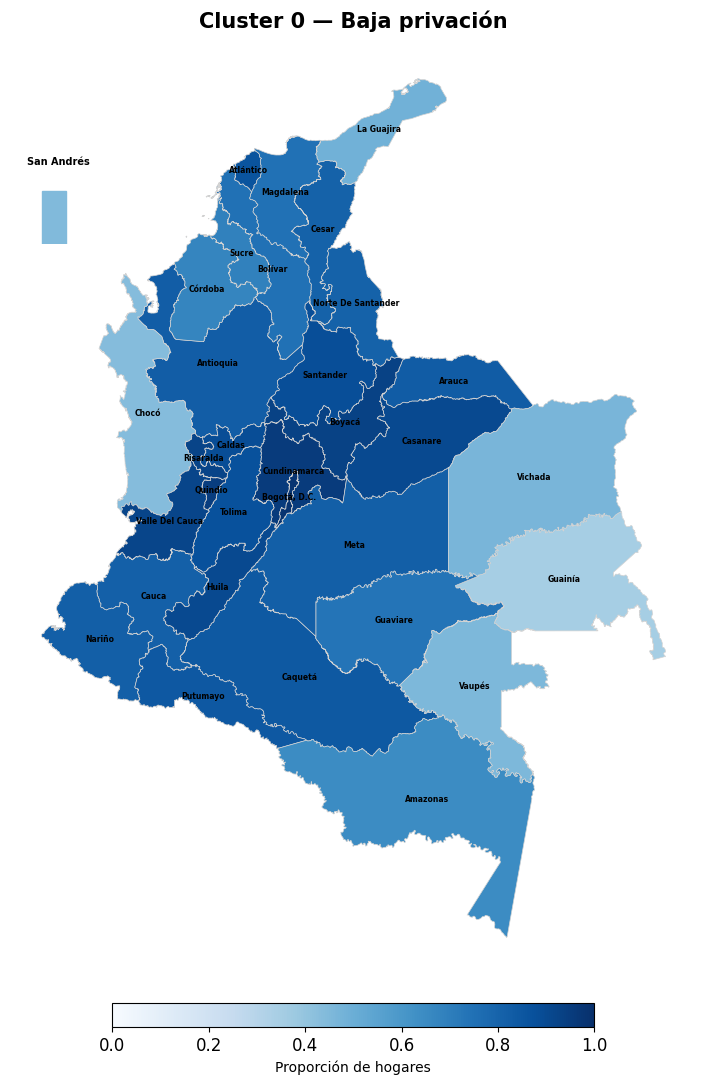

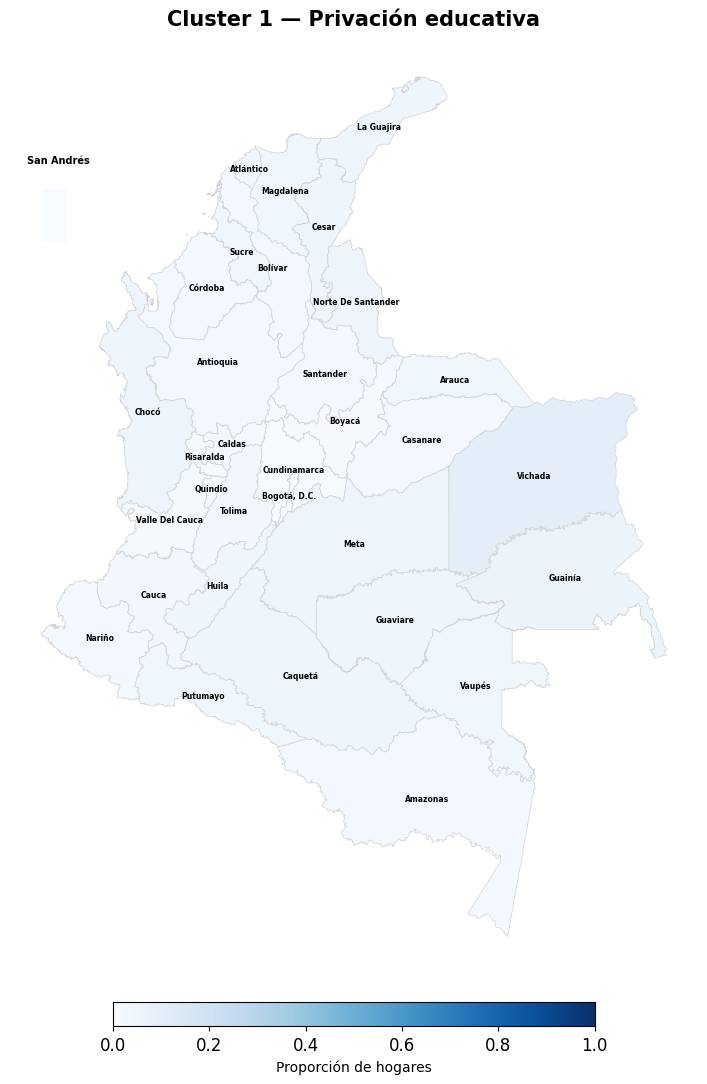

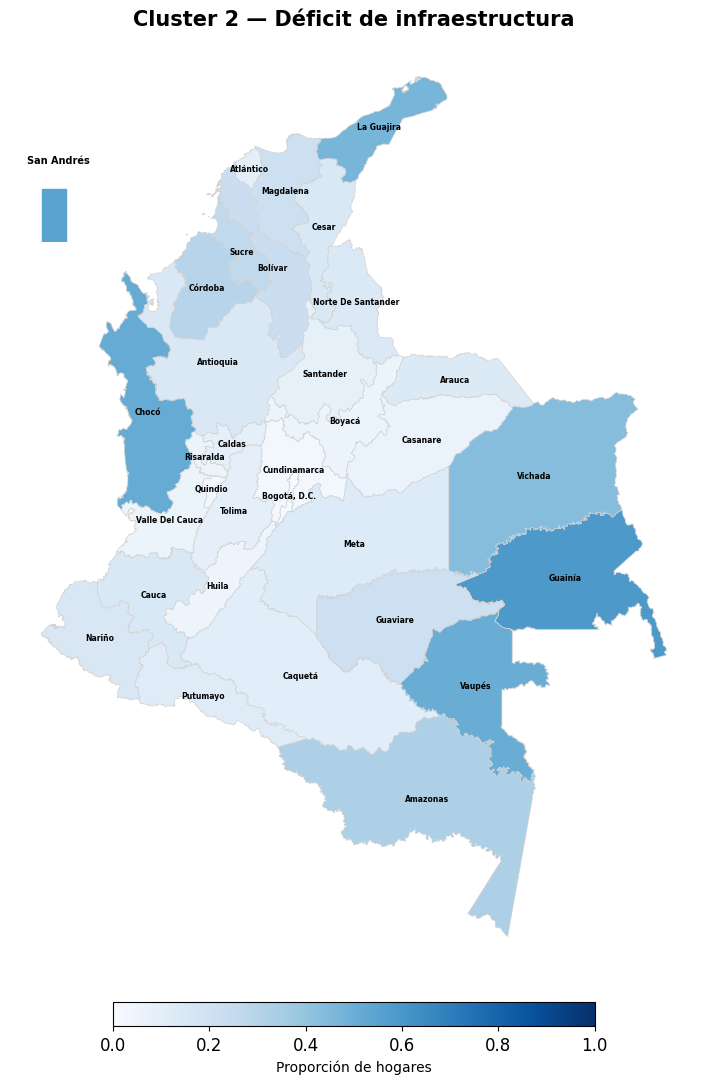

In [ ]:
# Diccionario de nombres
nombres_dept = {
    5: "Antioquia", 8: "Atlántico", 11: "Bogotá D.C.", 13: "Bolívar",
    15: "Boyacá", 17: "Caldas", 18: "Caquetá", 19: "Cauca",
    20: "Cesar", 23: "Córdoba", 25: "Cundinamarca", 27: "Chocó",
    41: "Huila", 44: "La Guajira", 47: "Magdalena", 50: "Meta",
    52: "Nariño", 54: "Nte. de Santander", 63: "Quindío", 66: "Risaralda",
    68: "Santander", 70: "Sucre", 73: "Tolima", 76: "Valle del Cauca",
    81: "Arauca", 85: "Casanare", 86: "Putumayo", 88: "San Andrés",
    91: "Amazonas", 94: "Guainía", 95: "Guaviare", 97: "Vaupés", 99: "Vichada"
}

# Cluster predominante por departamento
perfil_dept = ipm_analisis.copy()
perfil_dept['cluster'] = labels_km

cluster_predominante = perfil_dept.groupby('DEPARTAMENTO')['cluster'].agg(
    lambda x: x.value_counts().idxmax()
).reset_index()
cluster_predominante.columns = ['DEPARTAMENTO', 'cluster_predominante']

# Cruce con shapefile
colombia['dpto_ccdgo'] = colombia['dpto_ccdgo'].astype(int)
mapa = colombia.merge(cluster_predominante, left_on='dpto_ccdgo', right_on='DEPARTAMENTO', how='left')

# Mapa
titulos = [
    'Cluster 0 — Baja privación',
    'Cluster 1 — Privación educativa',
    'Cluster 2 — Déficit de infraestructura'
]

for c, titulo in enumerate(titulos):

    prop = perfil_dept.groupby('DEPARTAMENTO').apply(
        lambda x: (x['cluster'] == c).mean()
    ).reset_index()
    prop.columns = ['DEPARTAMENTO', 'proporcion']

    mapa_c = colombia.merge(prop, left_on='dpto_ccdgo', right_on='DEPARTAMENTO', how='left')

    san_andres = mapa_c[mapa_c['dpto_ccdgo'] == 88]
    continental = mapa_c[mapa_c['dpto_ccdgo'] != 88]

    fig, ax = plt.subplots(figsize=(10, 12))

    continental.plot(
        column='proporcion',
        ax=ax,
        cmap='Blues',
        edgecolor='lightgray',
        linewidth=0.5,
        vmin=0, vmax=1,
        legend=False
    )

    for _, row in continental.iterrows():
        if row['geometry'] is not None:
            centroid = row['geometry'].centroid
            ax.annotate(
                row['dpto_cnmbr'].title(),
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=5.5, color='black', fontweight='bold'
            )

    proporcion_sa = san_andres['proporcion'].values[0] if not san_andres.empty else 0
    color_sa = plt.cm.Blues(proporcion_sa)

    axins = ax.inset_axes([0.01, 0.78, 0.12, 0.08])
    axins.add_patch(plt.Rectangle((0.3, 0), 0.3, 0.7, color=color_sa))
    axins.set_xlim(0, 1)
    axins.set_ylim(0, 1)
    axins.set_axis_off()
    axins.set_title('San Andrés', fontsize=7, fontweight='bold', pad=2)

    sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', shrink=0.5, pad=0.02)
    cbar.set_label('Proporción de hogares', fontsize=10)

    ax.set_title(titulo, fontsize=15, fontweight='bold')
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()

Los mapas confirman que los perfiles de pobreza **tienen una distribución territorial clara en Colombia**.

- El **Cluster 0** (baja privación) domina en la mayor parte del territorio, especialmente en el centro del país — **Bogotá, Cundinamarca, Antioquia, Santander y el eje cafetero** concentran las proporciones más altas. Son los departamentos con mayor desarrollo relativo y mejor acceso a servicios.

- El **Cluster 1** (privación educativa) tiene presencia muy baja en casi todos los departamentos, lo que sugiere que este perfil no está concentrado territorialmente sino **disperso a lo largo del país**. Los hogares con estas carencias coexisten con otros perfiles en los mismos departamentos.

- El **Cluster 2** (déficit de infraestructura) muestra una concentración clara en la periferia del país: **Chocó, La Guajira, Vichada, Guainía y Vaupés** son los departamentos con mayor proporción de hogares en este grupo. Son precisamente los departamentos históricamente más rezagados en términos de cobertura de servicios públicos y conexión con el resto del territorio nacional.

En conjunto, los mapas sugieren que la **pobreza por infraestructura** tiene una dimensión territorial muy definida mientras que la **pobreza educativa** es más transversal y no responde a una geografía específica.

---

# **Sección 4. Conclusiones**

---

## **4.1 ¿Qué encontramos?**

El análisis muestra que la pobreza multidimensional **no es homogénea**. Se identificaron tres perfiles principales:

- Un grupo mayoritario (79% de los hogares) con **bajos niveles de privación**.
- Un perfil **educativo**, pequeño pero con la mayor incidencia de pobreza, caracterizado por rezago escolar, inasistencia y trabajo infantil.
- Un perfil de **infraestructura**, asociado a carencias en servicios básicos y vivienda, concentrado principalmente en departamentos periféricos del país.

Estos resultados evidencian que las privaciones se manifiestan de formas distintas según el contexto de los hogares.

## **4.2 Limitaciones**

Al trabajar con variables **binarias**, el **ACP** solo logra capturar una parte de la variabilidad total de los datos.

Además, debido al **tamaño** de nuestro **dataset** no se pudo aplicar directamente el **clustering jerárquico** sobre toda la muestra, por lo que se utilizó una aproximación basada en centroides.

Finalmente, el análisis es principalmente **descriptivo**, por lo que permite identificar **perfiles de pobreza**, pero no establecer relaciones de causalidad entre las privaciones observadas.

## **4.3 Recomendación**

Los perfiles identificados muestran que la **pobreza multidimensional** se manifiesta de formas **diferentes entre los hogares**. Mientras algunos grupos presentan principalmente privaciones educativas, otros concentran carencias relacionadas con infraestructura y servicios básicos.

Esto sugiere que el estudio de la pobreza puede enriquecerse al considerar no solo su **intensidad**, sino también el **tipo de privaciones** que enfrentan los hogares.

---

# **Sección 5. Uso de IA**

---


## **5.1 ¿Para qué se usó?**

Durante el desarrollo de este proyecto se utilizó **Claude** como herramienta de apoyo.

Se consultaron aspectos relacionados con la selección de **métodos** de reducción de dimensionalidad y clustering, se solicitó ayuda para la construcción de algunas **visualizaciones** y se empleó para la **resolución de errores** de programación.

Además, sirvió como apoyo en la **redacción** inicial de interpretaciones y descripciones de resultados, para que estos tuvieran un tono un poco más adecuado que el que tenían incialmente.

## **5.2 ¿Qué se ajustó?**

Las respuestas generadas por la IA no fueron incorporadas de forma inmediat,tanto el código como los textos requirieron **revisión y ajustes posteriores**, especialmente en aspectos de formato, claridad y adaptación al estilo del notebook.

Adicionalmente, las interpretaciones fueron contrastadas con los resultados obtenidos antes de ser incluidas en el informe.

## **5.3 Criterio propio**

La IA sirvió principalmente como apoyo durante el desarrollo del trabajo, las decisiones metodológicas y las conclusiones finales no se tomaron automáticamente a partir de sus sugerencias, sino después de **revisar los resultados obtenidos y contrastarlos con los objetivos del análisis**.

---

# **Sección 6. Enlaces**

---

A continuación presentamos dos enlaces, uno correspondiente al repositorio de Github y el otro, correspondiente a la aplicación alojada en Streamlit que contiene los resultados más relevantes de este proyecto.

[**Github**](https://github.com/JohanAv1018/Proyecto-Final---Diplomado/tree/main)

[**Aplicación en Stremlit**](https://pobreza-multidimensional-colombia.streamlit.app/)